In [ ]:
pip install qiskit qiskit-aer pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.7 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=8a1f13be1219d22eb6252f4b35b8041a845a79d09c3fbcdfc346907564f4f699
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


##Circuit metrics and scheduling

tools to analyze the circuit's properties and timing


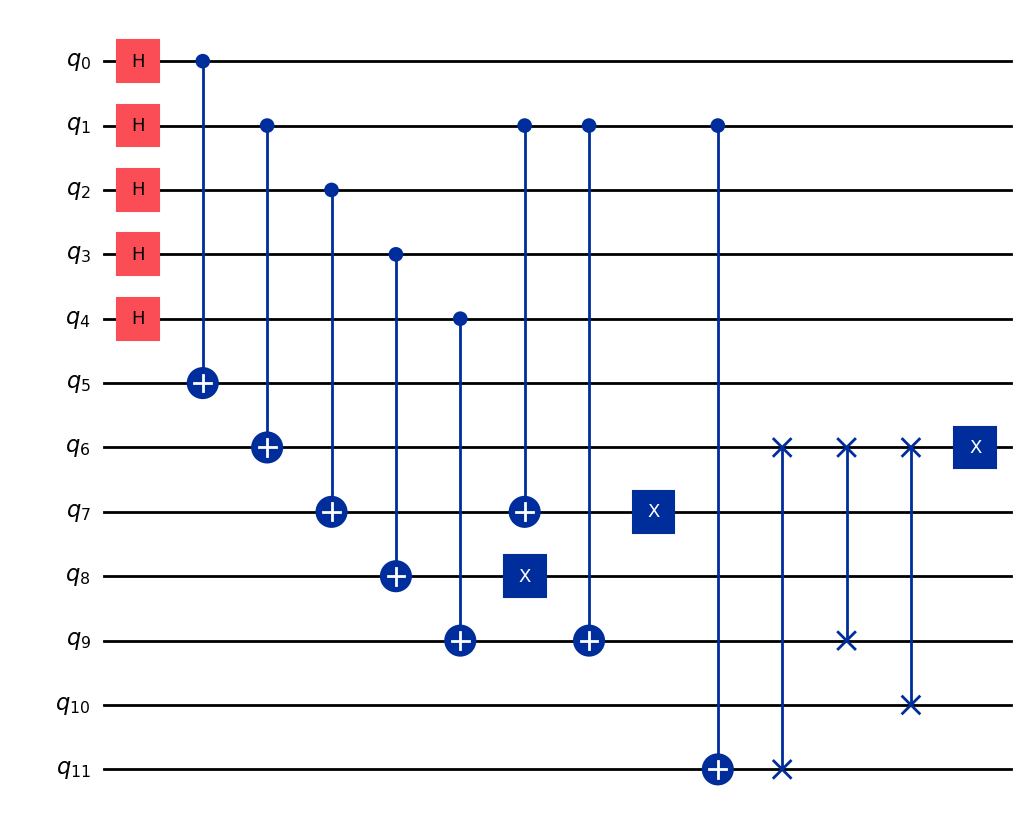

In [ ]:
from qiskit import QuantumCircuit
qc = QuantumCircuit(12)
for idx in range(5):
  qc.h(idx)
  qc.cx(idx, idx+5)

qc.cx(1, 7)
qc.x(8)
qc.cx(1, 9)
qc.x(7)
qc.cx(1, 11)
qc.swap(6, 11)
qc.swap(6, 9)
qc.swap(6, 10)
qc.x(6)
qc.draw('mpl')


In [ ]:
assert qc.width() == 12

In [ ]:
assert qc.num_qubits == 12

In [ ]:
print(qc.depth())

9


$$
\begin{array}{|c|l|l|}
\hline
\textbf{Cell} & \textbf{Code} & \textbf{What it does} \\
\hline
[5] & \texttt{assert\ qc.width() == 12} & \text{Checks the circuit has exactly 12 wires} \\
\hline
[6] & \texttt{assert\ qc.num\_qubits == 12} & \text{Verifies there are exactly 12 qubits} \\
\hline
[8] & \texttt{print(qc.depth())} \rightarrow 9 & \text{Prints circuit depth (longest gate path)} \\
\hline
\end{array}
$$

In [ ]:
qc.count_ops()

OrderedDict([('cx', 8), ('h', 5), ('x', 3), ('swap', 3)])

The **qc.count_ops()** method in Qiskit returns an ordered dictionary of all gate operations used in the circuit, along with how many times each appears.

##**Accessing** Scheduling Information

### estimate_duration

Estimates the total duration of the circuit based on gate times provided by a backend.

In [ ]:
from qiskit.providers.fake_provider import GenericBackendV2
qc = QuantumCircuit(1)
qc.delay(100, 0, unit='dt')

# Use at least 2 qubits for the fake backend so multi-qubit basis gates exist

backend = GenericBackendV2(num_qubits=2)
qc.estimate_duration(backend.target)

2.22e-08

## `qc.delay()` — Idle Instruction

**Syntax:**
$$\texttt{qc.delay(duration, qubit, unit)}$$

**Example:**
$$\texttt{qc.delay(100, 0, unit='dt')}$$

---

### Arguments

| Argument | Value | Meaning |
|----------|-------|---------|
| `duration` | `100` | Wait for 100 time units |
| `qubit` | `0` | Applied on qubit $q_0$ |
| `unit` | `'dt'` | Device clock cycle (smallest hardware time unit) |

---

### Circuit Representation
$$q_0: \text{——}[\text{Delay}(100\,dt)]\text{——}$$

---

### Purpose
- **Synchronization** — align timing between qubits
- **Noise studies** — observe decoherence over idle time  
- **Dynamical Decoupling** — insert pauses before corrective pulses
- **Pulse scheduling** — fine-tune hardware-level timing

---

### Available Time Units

| Unit | Meaning |
|------|---------|
| `dt` | Device clock cycle *(hardware-native)* |
| `ns` | Nanoseconds |
| `us` | Microseconds |
| `ms` | Milliseconds |
| `s`  | Seconds |

> **Note:** On IBM quantum devices, $1\,dt \approx 0.222\,\text{ns}$

## **qubit_duration**

Returns the duration of operations on a specific qubit.